# Email Sentiment Agent — Evals

Measures how accurately the agent scores customer emails across four dimensions:

| Section | What is measured |
|---------|------------------|
| 1 · Test Cases | Browse the 40 hand-labeled emails |
| 2 · Run Evals | Call the agent on every test case (cached after first run) |
| 3 · Label Accuracy | Classification accuracy, per-class F1, confusion matrix |
| 4 · Score Calibration | Are predicted scores landing in the right range? |
| 5 · Urgency Detection | Recall/precision for high-urgency detection |
| 6 · LLM Judge | Sonnet grades theme relevance and summary quality |
| 7 · Failures | Inspect every wrong prediction |
| 8 · Report Card | Pass/fail per metric against thresholds |

In [24]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from eval_helpers import (
    load_test_cases,
    run_all_evals,
    compute_label_metrics,
    compute_score_calibration,
    compute_urgency_metrics,
    run_judge_evals,
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 80)

print('Setup complete.')

Setup complete.


---
## 1 · Test Cases

40 hand-labeled emails across 9 categories.  
Each has a ground-truth `sentiment`, expected `score_min/max`, and `urgency`.

In [25]:
test_cases = load_test_cases()

df_cases = pd.DataFrame([
    {
        'id':          tc['id'],
        'case_type':   tc['case_type'],
        'sentiment':   tc['expected']['sentiment'],
        'score_range': f"{tc['expected']['score_min']:+.1f} to {tc['expected']['score_max']:+.1f}",
        'urgency':     tc['expected']['urgency'],
        'subject':     tc['subject'][:60],
        'notes':       tc.get('notes', ''),
    }
    for tc in test_cases
])

pos = sum(1 for t in test_cases if t['expected']['sentiment'] == 'positive')
neu = sum(1 for t in test_cases if t['expected']['sentiment'] == 'neutral')
neg = sum(1 for t in test_cases if t['expected']['sentiment'] == 'negative')
print(f"{len(test_cases)} test cases  |  positive={pos}  neutral={neu}  negative={neg}")
df_cases

40 test cases  |  positive=7  neutral=7  negative=26


,id,case_type,sentiment,score_range,urgency,subject,notes
0,tc_001,clear_positive,positive,+0.7 to +1.0,low,Just received my order â€” absolutely delighted!,Unambiguous enthusiastic positive â€” baseline sanity check
1,tc_002,clear_positive,positive,+0.6 to +1.0,low,Third order this year and still impressed,Repeat customer satisfaction â€” should score high positive
2,tc_003,clear_positive,positive,+0.5 to +0.9,low,"Campaign discount â€” great deal, great product","Satisfied but measured â€” good value, not ecstatic"
3,tc_004,clear_positive,positive,+0.6 to +1.0,low,"Re: Summer Sale â€” bought as a gift, huge success",Gift purchase â€” happiness expressed on behalf of two people
4,tc_005,clear_positive,positive,+0.7 to +1.0,low,Ordered for the whole team â€” everyone's thrilled,Team/bulk order â€” strong advocacy signal
5,tc_006,clear_positive,positive,+0.7 to +1.0,low,Already reordered â€” best campaign you've done,Immediate reorder â€” strongest positive buying behaviour signal
6,tc_007,clear_neutral,neutral,-0.1 to +0.2,low,Order status enquiry,"Polite status check â€” explicitly says 'not worried', no frustration"
7,tc_008,clear_neutral,neutral,-0.1 to +0.2,low,Return policy for campaign purchases?,"Return request â€” product fine, just wrong fit, no negative emotion"
8,tc_009,clear_neutral,neutral,-0.1 to +0.2,low,Delivery estimate for my order?,"Practical delivery question â€” no frustration, just logistics"
9,tc_010,clear_neutral,neutral,-0.1 to +0.2,low,Order arrived â€” will review once I've tried it,"Deliberately non-committal â€” 'okay', no strong signal either way"


---
## 2 · Run Evals

Calls the agent (Haiku) on every test case.  
Results are saved to `results.json` — re-running this cell skips cached cases.

In [26]:
results = run_all_evals(test_cases, skip_existing=True)

valid   = [r for r in results if 'predicted_sentiment' in r]
errored = [r for r in results if 'error' in r]
print(f"\nTotal: {len(results)}  |  Valid: {len(valid)}  |  Errors: {len(errored)}")
for e in errored:
    print(f"  ERROR {e['id']}: {e['error']}")

  [cached]  tc_001
  [cached]  tc_002
  [cached]  tc_003
  [cached]  tc_004
  [cached]  tc_005
  [cached]  tc_006
  [cached]  tc_007
  [cached]  tc_008
  [cached]  tc_009
  [cached]  tc_010
  [cached]  tc_011
  [cached]  tc_012
  [cached]  tc_013
  [cached]  tc_014
  [cached]  tc_015
  [cached]  tc_016
  [cached]  tc_017
  [cached]  tc_018
  [cached]  tc_019
  [cached]  tc_020
  [cached]  tc_021
  [cached]  tc_022
  [cached]  tc_023
  [cached]  tc_024
  [cached]  tc_025
  [cached]  tc_026
  [cached]  tc_027
  [cached]  tc_028
  [cached]  tc_029
  [cached]  tc_030
  [cached]  tc_031
  [cached]  tc_032
  [cached]  tc_033
  [cached]  tc_034
  [cached]  tc_035
  [cached]  tc_036
  [cached]  tc_037
  [cached]  tc_038
  [cached]  tc_039
  [cached]  tc_040

Total: 40  |  Valid: 40  |  Errors: 0


---
## 3 · Label Accuracy

Overall accuracy and per-class precision, recall, F1.  
The confusion matrix shows which classes get confused with each other.

In [27]:
metrics = compute_label_metrics(results)

print(f"Overall accuracy: {metrics['accuracy']:.1%}  ({metrics['correct']}/{metrics['total']} correct)\n")

df_pc = pd.DataFrame(metrics['per_class']).T
df_pc.index.name = 'class'
df_pc

Overall accuracy: 97.5%  (39/40 correct)



,precision,recall,f1,support
class,,,,
positive,1.000,1.000,1.000,7.0
neutral,1.000,0.857,0.923,7.0
negative,0.963,1.000,0.981,26.0


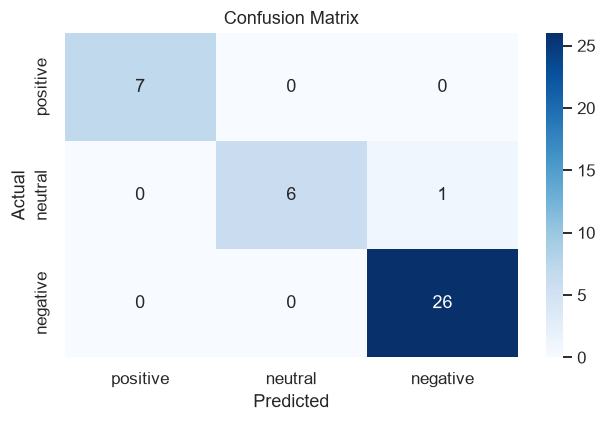

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    metrics['confusion_matrix'],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=metrics['classes'],
    yticklabels=metrics['classes'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 4 · Score Calibration

Are the predicted numeric scores landing in the expected range per class?  
The box plot shows spread; the table shows what fraction passed the range check.

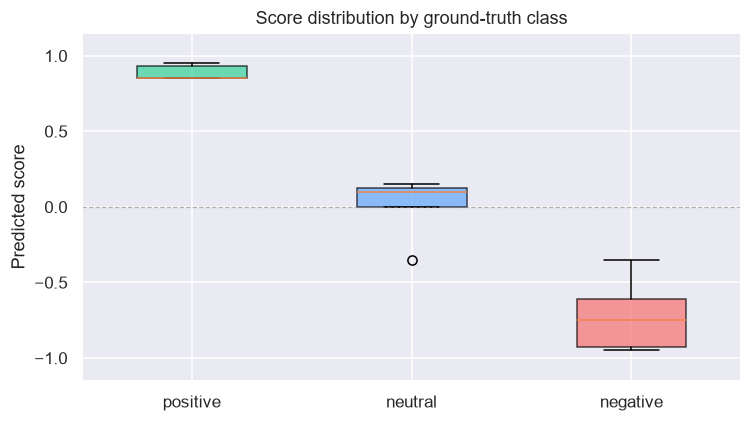

,mean,min,max,in_range
class,,,,
positive,0.889,0.85,0.95,7/7 (100%)
neutral,0.021,-0.35,0.15,6/7 (86%)
negative,-0.716,-0.95,-0.35,21/26 (81%)


In [29]:
cal = compute_score_calibration(results)

classes = ['positive', 'neutral', 'negative']
colours = ['#34d399', '#60a5fa', '#f87171']
plot_data   = [cal[c]['scores'] for c in classes if c in cal]
plot_labels = [c for c in classes if c in cal]

fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(plot_data, patch_artist=True, widths=0.5)
ax.set_xticklabels(plot_labels)
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylabel('Predicted score')
ax.set_ylim(-1.15, 1.15)
ax.set_title('Score distribution by ground-truth class')
plt.tight_layout()
plt.show()

rows = []
for c in classes:
    if c not in cal:
        continue
    total_c  = sum(1 for r in results if r.get('expected_sentiment') == c and 'predicted_score' in r)
    in_range = sum(1 for r in results if r.get('expected_sentiment') == c and r.get('score_in_range'))
    pct = f"{in_range/total_c:.0%}" if total_c else 'n/a'
    rows.append({'class': c, 'mean': cal[c]['mean'], 'min': cal[c]['min'],
                 'max': cal[c]['max'], 'in_range': f"{in_range}/{total_c} ({pct})"})
pd.DataFrame(rows).set_index('class')

---
## 5 · Urgency Detection

A missed `high`-urgency email is a real business risk (legal threat, chargeback, viral post).  
**Recall is the primary metric** — we prefer over-flagging to missing a real escalation.

In [30]:
urg = compute_urgency_metrics(results)

print(f"High-urgency detection")
print(f"  Precision : {urg['precision']:.3f}")
print(f"  Recall    : {urg['recall']:.3f}  <- primary metric")
print(f"  F1        : {urg['f1']:.3f}")
print(f"  TP={urg['tp']}  FP={urg['fp']}  FN={urg['fn']}\n")

df_urg = pd.DataFrame(urg['high_urgency_cases'])
if not df_urg.empty:
    display(df_urg)
else:
    print("No high-urgency cases in results yet.")

High-urgency detection
  Precision : 0.700
  Recall    : 1.000  <- primary metric
  F1        : 0.824
  TP=7  FP=3  FN=0



,id,subject,expected,predicted,correct
0,tc_014,Delivery now 10 days overdue,medium,high,False
1,tc_017,"Three support tickets, zero responses",medium,high,False
2,tc_020,Defective product â€” want a replacement,medium,high,False
3,tc_034,FULL REFUND REQUIRED â€” final request before bank disp,high,high,True
4,tc_035,Small claims court â€” last chance,high,high,True
5,tc_036,Complaint filed with consumer authority,high,high,True
6,tc_037,"Sharing this with my 14,000 followers unless resolved t",high,high,True
7,tc_038,FINAL NOTICE,high,high,True
8,tc_039,Chargeback initiated,high,high,True
9,tc_040,Legal advice obtained regarding misleading campaign,high,high,True


---
## 6 · LLM Judge — Themes & Summary Quality

Uses `claude-sonnet-4-6` (a different, stronger model) to grade two dimensions:

- **theme_score 1–3** — are the extracted themes accurate and present in the email?  
- **summary_score 1–3** — does the summary correctly capture the sentiment and main point?

Results are cached to `judge_results.json`.

In [31]:
judge_results = run_judge_evals(results, skip_existing=True)

valid_j = [j for j in judge_results if j.get('theme_score') is not None]
print(f"\nJudged: {len(valid_j)}/{len(results)}")

  [judging] tc_001  Just received my order â€” absolutely delighted!... themes=3/3  summary=3/3
  [judging] tc_002  Third order this year and still impressed... themes=3/3  summary=3/3
  [judging] tc_003  Campaign discount â€” great deal, great product... themes=3/3  summary=3/3
  [judging] tc_004  Re: Summer Sale â€” bought as a gift, huge success... themes=3/3  summary=3/3
  [judging] tc_005  Ordered for the whole team â€” everyone's thrilled... themes=3/3  summary=3/3
  [judging] tc_006  Already reordered â€” best campaign you've done... themes=3/3  summary=3/3
  [judging] tc_007  Order status enquiry... themes=3/3  summary=3/3
  [judging] tc_008  Return policy for campaign purchases?... themes=3/3  summary=3/3
  [judging] tc_009  Delivery estimate for my order?... themes=3/3  summary=3/3
  [judging] tc_010  Order arrived â€” will review once I've tried it... themes=3/3  summary=3/3
  [judging] tc_011  Question about product specs before I order... themes=3/3  summary=3/3
  [judging

Average theme score  : 2.92 / 3
Average summary score: 2.95 / 3


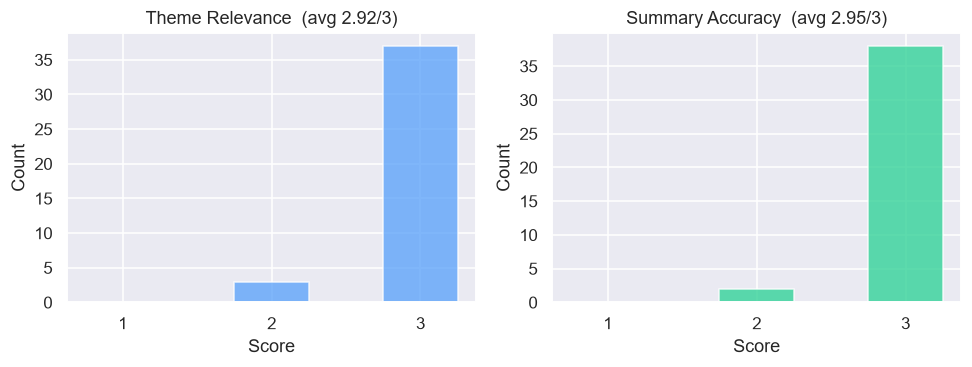


All cases scored 2 or above on both dimensions.


In [32]:
if valid_j:
    theme_scores   = [j['theme_score']   for j in valid_j]
    summary_scores = [j['summary_score'] for j in valid_j]
    avg_t = sum(theme_scores)   / len(theme_scores)
    avg_s = sum(summary_scores) / len(summary_scores)

    print(f"Average theme score  : {avg_t:.2f} / 3")
    print(f"Average summary score: {avg_s:.2f} / 3")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    for ax, scores, title, colour in zip(
        axes,
        [theme_scores, summary_scores],
        ['Theme Relevance', 'Summary Accuracy'],
        ['#60a5fa', '#34d399'],
    ):
        counts = [scores.count(v) for v in [1, 2, 3]]
        ax.bar([1, 2, 3], counts, color=colour, alpha=0.8, width=0.5)
        ax.set_xticks([1, 2, 3])
        ax.set_xlabel('Score')
        ax.set_ylabel('Count')
        ax.set_title(f"{title}  (avg {sum(scores)/len(scores):.2f}/3)")
    plt.tight_layout()
    plt.show()

    low = [j for j in valid_j if j['theme_score'] < 2 or j['summary_score'] < 2]
    if low:
        print(f"\nCases scoring below 2 on any dimension ({len(low)}):")
        df_low = pd.DataFrame([{
            'id':           j['id'],
            'subject':      j['subject'][:55],
            'theme':        j['theme_score'],
            'summary':      j['summary_score'],
            'judge_notes':  j['judge_notes'],
        } for j in low])
        display(df_low)
    else:
        print("\nAll cases scored 2 or above on both dimensions.")

---
## 7 · Failures

Every case where the predicted label differs from ground truth.

In [33]:
failures = [r for r in results if 'predicted_sentiment' in r and not r['label_correct']]
valid_count = len([r for r in results if 'predicted_sentiment' in r])
print(f"{len(failures)} failure(s) out of {valid_count} valid results\n")

for r in failures:
    print('-' * 70)
    print(f"ID        : {r['id']}  [{r['case_type']}]")
    print(f"Subject   : {r['subject']}")
    print(f"Expected  : {r['expected_sentiment']:<10}  range [{r['expected_score_min']:+.1f}, {r['expected_score_max']:+.1f}]  urgency={r['expected_urgency']}")
    print(f"Predicted : {r['predicted_sentiment']:<10}  score={r['predicted_score']:+.2f}  urgency={r['predicted_urgency']}")
    print(f"Themes    : {', '.join(r.get('predicted_themes', []))}")
    print(f"Summary   : {r.get('predicted_summary', '')}")
    print(f"Notes     : {r.get('notes', '')}")
    print()

1 failure(s) out of 40 valid results

----------------------------------------------------------------------
ID        : tc_028  [edge_mixed]
Subject   : Love the product, hate the packaging
Expected  : neutral     range [-0.2, +0.2]  urgency=low
Predicted : negative    score=-0.35  urgency=low
Themes    : product quality (positive), packaging quality (negative), damage during shipping, improvement request
Summary   : Customer is satisfied with the product itself but disappointed by poor packaging and damage, requesting operational improvements.
Notes     : Genuinely balanced â€” strong positive on product, clear negative on packaging, roughly even



---
## 8 · Report Card

Pass/fail per metric against minimum quality thresholds.  
Adjust the thresholds at the top of the cell to match your requirements.

In [34]:
# Thresholds — adjust to your quality bar
THRESHOLD_ACCURACY        = 0.80
THRESHOLD_NEG_F1          = 0.75
THRESHOLD_URGENCY_RECALL  = 0.85
THRESHOLD_SCORE_RANGE     = 0.70
THRESHOLD_JUDGE_THEME     = 2.0
THRESHOLD_JUDGE_SUMMARY   = 2.0

m   = compute_label_metrics(results)
u   = compute_urgency_metrics(results)
valid_r = [r for r in results if 'predicted_score' in r]
in_range_pct = sum(1 for r in valid_r if r['score_in_range']) / len(valid_r) if valid_r else 0

valid_j = [j for j in judge_results if j.get('theme_score') is not None]
avg_theme   = sum(j['theme_score']   for j in valid_j) / len(valid_j) if valid_j else 0
avg_summary = sum(j['summary_score'] for j in valid_j) / len(valid_j) if valid_j else 0

checks = [
    ('Overall accuracy',          m['accuracy'],                        THRESHOLD_ACCURACY,       '.1%'),
    ('Negative-class F1',         m['per_class']['negative']['f1'],     THRESHOLD_NEG_F1,         '.3f'),
    ('Urgency recall (high)',      u['recall'],                          THRESHOLD_URGENCY_RECALL, '.3f'),
    ('Score in expected range',    in_range_pct,                         THRESHOLD_SCORE_RANGE,    '.1%'),
    ('Judge avg theme score',      avg_theme,                            THRESHOLD_JUDGE_THEME,    '.2f'),
    ('Judge avg summary score',    avg_summary,                          THRESHOLD_JUDGE_SUMMARY,  '.2f'),
]

print(f"{'Metric':<32} {'Value':>8}  {'Threshold':>9}  Status")
print('-' * 62)
all_pass = True
for name, value, threshold, fmt in checks:
    passed    = value >= threshold
    all_pass  = all_pass and passed
    mark      = 'PASS' if passed else 'FAIL'
    print(f"{name:<32} {format(value, fmt):>8}  {format(threshold, fmt):>9}  {mark}")
print('-' * 62)
print()
print('ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED - see sections above for details')

Metric                              Value  Threshold  Status
--------------------------------------------------------------
Overall accuracy                    97.5%      80.0%  PASS
Negative-class F1                   0.981      0.750  PASS
Urgency recall (high)               1.000      0.850  PASS
Score in expected range             85.0%      70.0%  PASS
Judge avg theme score                2.92       2.00  PASS
Judge avg summary score              2.95       2.00  PASS
--------------------------------------------------------------

ALL CHECKS PASSED
